https://app.neptune.ai/pmtest/llm-random/


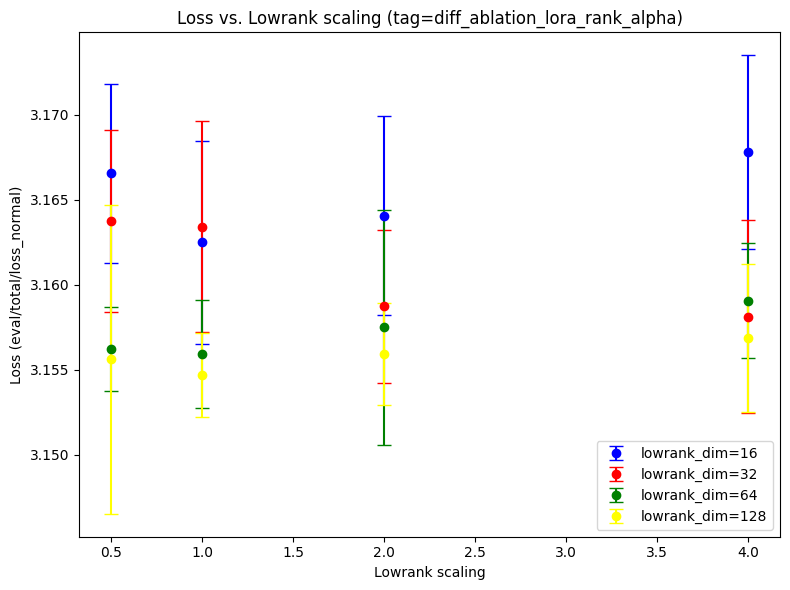

In [2]:
import neptune
import matplotlib.pyplot as plt

# Initialize Neptune (make sure your API token and project are set, e.g. via environment variables)
# e.g. NEPTUNE_API_TOKEN and NEPTUNE_PROJECT
Y_AXIS_COL = "eval/total_loss/normal"
LOWRANK_DIM_COL = "args/diff_transformer_lowrank_dim"
LOWRANK_SCALING_COL = "args/diff_transformer_lowrank_scaling"

run_table = neptune.init_project(project="pmtest/llm-random").fetch_runs_table(
    tag=["diff_ablation_lora_rank_alpha"],
    columns=[
        "sys/id",
        LOWRANK_DIM_COL,
        LOWRANK_SCALING_COL,
        Y_AXIS_COL,
    ],
)
plot_df = run_table.to_pandas()
plot_df = plot_df.sort_values(by=[LOWRANK_SCALING_COL, LOWRANK_DIM_COL])
plot_df.dropna(inplace=True)

# Plot
plt.figure(figsize=(8, 6))
color_map = {16: "blue", 32: "red", 64: "green", 128: "yellow"} # Updated color_map for lowrank_dim to reflect dims from 16 to 128
for lowrank_dim, subdf in plot_df.groupby(LOWRANK_DIM_COL): # Group by LOWRANK_DIM_COL for outer loop
    if lowrank_dim not in color_map:
        continue
    color = color_map.get(lowrank_dim)

    grouped = subdf.groupby(LOWRANK_SCALING_COL) # Group by LOWRANK_SCALING_COL for x-axis
    means = grouped[Y_AXIS_COL].mean()
    stds = grouped[Y_AXIS_COL].std()
    x_values = means.index # x_values are now lowrank_scaling

    plt.errorbar(
        x=x_values.to_numpy(),
        y=means.to_numpy(),
        yerr=stds.to_numpy(),
        fmt="o",
        color=color,
        label=f"lowrank_dim={lowrank_dim}", # Label by lowrank_dim
        capsize=5,
    )

# plt.xscale("log")
plt.xlabel("Lowrank scaling") # Changed x-axis label
plt.ylabel("Loss (eval/total/loss_normal)")
plt.title("Loss vs. Lowrank scaling (tag=diff_ablation_lora_rank_alpha)") # Changed title
plt.legend()
plt.tight_layout()
plt.show()


In [ ]:
# plot_df
# #%%
# for lowrank_dim, subdf in plot_df.groupby("args/diff_transformer_lowrank_dim"):
#     print(f"Lowrank dim: {lowrank_dim}")
#     print(subdf[["args/diff_transformer_lowrank_dim", "eval/total_loss/normal"]])
#     a = subdf
# #%%
# # a.groupby("args/diff_transformer_lowrank_scaling")["eval/total_loss/normal"].mean().to_numpy()
# # #%%
# # a.groupby("args/diff_transformer_lowrank_scaling")["args/diff_transformer_lowrank_scaling"].mean().to_numpy()
# # #%%
# # for lowrank_dim, qdf in a.groupby("args/diff_transformer_lowrank_dim"):
# #     print(f"Lowrank dim: {lowrank_dim}")
# #     print(qdf[["args/diff_transformer_lowrank_scaling", "eval/total_loss/normal"]])
# #     b = qdf

# # b.mean(

# # )
# # # plt.plot(
# # #             b["args/diff_transformer_lowrank_scaling"].to_numpy(),
# # #             b[Y_AXIS_COL].to_numpy(),
# # #             # linestyle=linestyle,
# # #             # color=color,
# # #             # label=f"{lowrank_scaling}, lowrank_dim={lowrank_dim}",
# # #         )
# # # b["args/diff_transformer_lowrank_scaling"].to_numpy()
# # # b[Y_AXIS_COL].to_numpy()
# # # plt.plot([50], [2.6])
# # #%%
# # b
# # #%%
# # b[Y_AXIS_COL].to_numpy().mean()
